In [5]:
import re
import requests
import string
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import tiktoken
from transformers import BertTokenizer

# BERT

In [40]:
# load BERT tokenizer, base uncased means that it will convert all text to lowercase and use the base version of the model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# check what it means every token ID in "Hello, world!"
for token_id in tokenizer.encode("Hello, World!"): # it will be converted to lowercase
    print(f"Token ID: {token_id}, Token: '{tokenizer.decode([token_id])}'")

Token ID: 101, Token: '[CLS]'
Token ID: 7592, Token: 'hello'
Token ID: 1010, Token: ','
Token ID: 2088, Token: 'world'
Token ID: 999, Token: '!'
Token ID: 102, Token: '[SEP]'


In [ ]:
tokenizer.encode("Hello"), tokenizer.encode("hello") # same tokens since they are converted to lowercase

([101, 7592, 102], [101, 7592, 102])

In [25]:
print(tokenizer.vocab_size) # size of the vocabulary
list(tokenizer.get_vocab().keys())[:10] # show the first 10 tokens in the vocabulary

30522


['323',
 '##।',
 'schmidt',
 'configurations',
 '305',
 'displaced',
 'consistency',
 'nests',
 'dumb',
 'bombers']

In [ ]:
# tokenize a word

word = "science"
res1 = tokenizer.get_vocab().get(word) # check if the word is in the vocabulary
res2 = tokenizer.convert_tokens_to_ids(word) # convert the word to its token ID
res3 = tokenizer.tokenize(word) # tokenize the word into subwords

print(f"Token ID for '{word}': {res1}")
print(f"Token ID for '{word}': {res2}")
print(f"Tokenized '{word}': {res3}")

print("-"*50)

word = "unhappiness"
res1 = tokenizer.get_vocab().get(word) # check if the word is in the vocabulary
res2 = tokenizer.convert_tokens_to_ids(word) # convert the word to its token ID
res3 = tokenizer.tokenize(word) # tokenize the word into subwords

print(f"Token ID for '{word}': {res1}") # the word is not in the vocabulary, so it returns None
print(f"Token ID for '{word}': {res2}") # the word is not in the vocabulary, so it returns the token ID for [UNK] (unknown token), which is 100
print(f"Tokenized '{word}': {res3}") # the word is tokenized into subwords: 'un', '##happiness' (the '##' indicates that it is a continuation of the previous token)

Token ID for 'science': 2671
Token ID for 'science': 2671
Tokenized 'science': ['science']
--------------------------------------------------
Token ID for 'unhappiness': None
Token ID for 'unhappiness': 100
Tokenized 'unhappiness': ['un', '##ha', '##pp', '##iness']


In [ ]:
sentence = "science is great"
res1 = tokenizer.get_vocab().get(sentence) # check if the word is in the vocabulary
res2 = tokenizer.convert_tokens_to_ids(sentence) # convert the word to its token ID
res3 = tokenizer.tokenize(sentence) # tokenize the word into subwords

print(f"Token ID for '{sentence}': {res1}") # fails since the sentence is not in the vocabulary, it returns None
print(f"Token ID for '{sentence}': {res2}")
print(f"Tokenized '{sentence}': {res3}")

print("-"*50)
sentence_encoded = tokenizer.encode(sentence) # encode the sentence into token IDs
print(sentence_encoded) # encode the sentence into token IDs, adds automatically special tokens like [CLS] and [SEP] that are added by the tokenizer for BERT models
print(tokenizer.decode(sentence_encoded)) # decode the token IDs back to the original sentence
print(tokenizer.decode(sentence_encoded, skip_special_tokens=True)) # we skip special tokens like [CLS] and [SEP] that are added by the tokenizer for BERT models
# [CLS] = classification token, it is added at the beginning of the sentence and is used for classification tasks
# [SEP] = separator token, it is added at the end of the sentence and is used to separate different sentences in tasks like question answering or sentence pair classification

Token ID for 'science is great': None
Token ID for 'science is great': 100
Tokenized 'science is great': ['science', 'is', 'great']
--------------------------------------------------
[101, 2671, 2003, 2307, 102]
[CLS] science is great [SEP]
science is great


In [49]:
 # we can also use the tokenizer as a function, it will return a dictionary with 
 # the token IDs and attention mask (which is used to indicate which tokens are padding and which are not)
print(tokenizer(sentence))
print(tokenizer(sentence).get('input_ids')) # we can access the token IDs directly from the dictionary

{'input_ids': [101, 2671, 2003, 2307, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}
[101, 2671, 2003, 2307, 102]


In [ ]:
from idna import decode


new_sentence = "AI is both exciting and scary"

tokenized = tokenizer.tokenize(new_sentence)
print(f"Tokenized: {tokenized}")

ids_from_tokens = tokenizer.convert_tokens_to_ids(tokenized)
print(f"Token IDs from tokens: {ids_from_tokens}") # as it is done from the tokens, it does not add special tokens like [CLS] and [SEP]

encoded = tokenizer.encode(new_sentence)
print(f"Encoded from sentence: {encoded}")

decoded = tokenizer.decode(encoded)
print(f"Decoded from sentence: {decoded}")

Tokenized: ['ai', 'is', 'both', 'exciting', 'and', 'scary']
Token IDs from tokens: [9932, 2003, 2119, 10990, 1998, 12459]
Encoded from sentence: [101, 9932, 2003, 2119, 10990, 1998, 12459, 102]
Decoded from sentence: [CLS] ai is both exciting and scary [SEP]


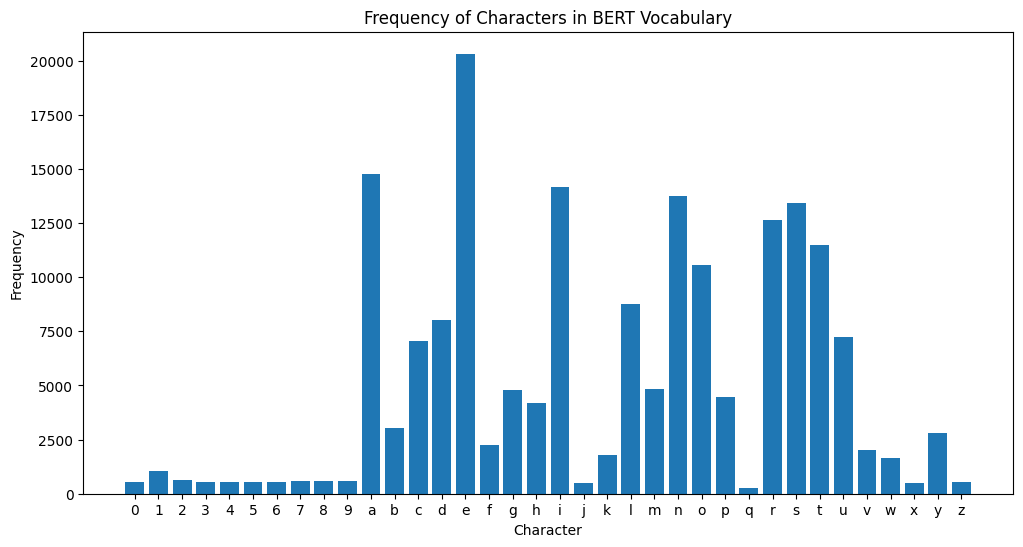

In [70]:
# frequency of characters in BERT vocabulary, filter just alphanumeric characters
digits_letters = string.digits + string.ascii_lowercase
char_count = np.zeros(len(digits_letters))
for token in tokenizer.get_vocab().keys():
    for char in token:
        if char in digits_letters:
            char_count[digits_letters.index(char)] += 1

plt.figure(figsize=(12, 6))
plt.bar(list(digits_letters), char_count)
plt.title("Frequency of Characters in BERT Vocabulary")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.show()